# Electronic Money and its recent possible impact on the acquire market

The main questin is :

**How has been evolving the electronic wallets in Peru? does it have an impact on the acquirer market?**

In [1]:
import sys
from functools import reduce
from pathlib import Path

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import catppuccin
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from matplotlib.ticker import StrMethodFormatter

from bcrp_analytics.utils import build_bcrp_dataset, get_bcrp_clean_series

pd.options.display.float_format = "{:,.2f}".format
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
plt.style.use("mocha")

# Fetch Data

In [2]:
card_payment_system_market = {
    # Total amount in millions
    "PN42164EM": "pago_tarjetas_total",
    "PN42165EM": "pago_tarjetas_debito",
    "PN42168EM": "pago_tarjetas_credito",
    "PN42166EM": "pago_tarjetas_debito_online",
    "PN42167EM": "pago_tarjetas_debito_offline",
    "PN42169EM": "pago_tarjetas_credito_online",
    "PN42170EM": "pago_tarjetas_credito_offline",
    # number of transactions in thousands
    "PN42193EM": "ntrx_tarjetas_total",
    "PN42194EM": "ntrx_tarjetas_debito",
    "PN42197EM": "ntrx_tarjetas_credito",
    "PN42195EM": "ntrx_tarjetas_debito_online",
    "PN42196EM": "ntrx_tarjetas_debito_offline",
    "PN42198EM": "ntrx_tarjetas_credito_online",
    "PN42199EM": "ntrx_tarjetas_credito_offline",
}

electronic_money = {
    "PN42209EM": "ntrx_dinero_electronico",
    "PN42180EM": "mto_dinero_electronico",
}

In [27]:
# card_payment_data = build_bcrp_dataset(payment_system_market)
electronic_data = build_bcrp_dataset(electronic_money)

In [4]:
electronic_data.head()

,period,ntrx_dinero_electronico,mto_dinero_electronico
0,2026-07-01,21.54,"2,538.07"
1,2026-06-01,19.70,"2,279.13"
2,2026-05-01,18.44,"2,175.01"
3,2026-04-01,17.01,"2,078.92"
4,2026-03-01,16.34,"2,379.56"


# Analyzing how payments via electronic wallets have evolved

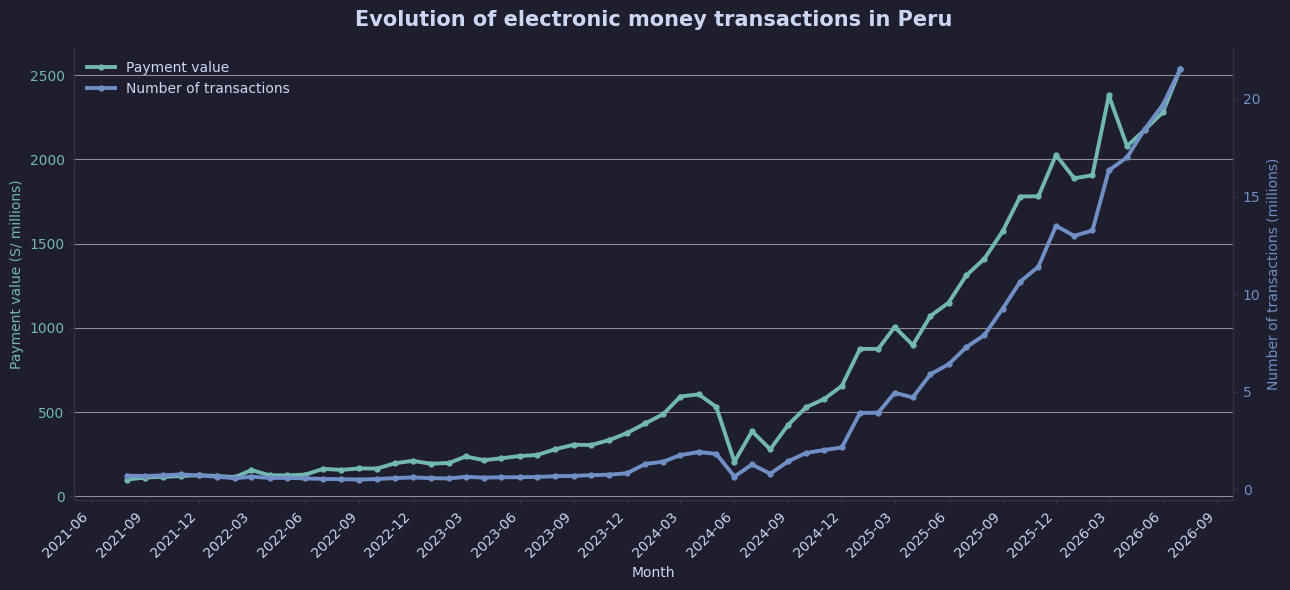

In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

electronic_data = electronic_data.sort_values("period").copy()

# Pastel corporate colors
value_color = "#72B7B2"
transactions_color = "#6F8FC5"

fig, ax1 = plt.subplots(figsize=(13, 6))

# Payment value — left axis
line_value = ax1.plot(
    electronic_data["period"],
    electronic_data["mto_dinero_electronico"],
    color=value_color,
    linewidth=2.8,
    marker="o",
    markersize=3.5,
    label="Payment value",
)

ax1.set_ylabel(
    "Payment value (S/ millions)",
    color=value_color,
)

ax1.tick_params(axis="y", labelcolor=value_color)

ax2 = ax1.twinx()

line_transactions = ax2.plot(
    electronic_data["period"],
    electronic_data["ntrx_dinero_electronico"],
    color=transactions_color,
    linewidth=2.8,
    marker="o",
    markersize=3.5,
    label="Number of transactions",
)

ax2.set_ylabel(
    "Number of transactions (millions)",
    color=transactions_color,
)

ax2.tick_params(axis="y", labelcolor=transactions_color)

# General formatting
ax1.set_title(
    "Evolution of electronic money transactions in Peru",
    fontsize=15,
    fontweight="bold",
    pad=16,
)

ax1.set_xlabel("Month")

ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.setp(
    ax1.get_xticklabels(),
    rotation=45,
    ha="right",
)

ax1.grid(
    axis="y",
    color="#D9D9D9",
    linewidth=0.8,
    alpha=0.6,
)

for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)

# Combined legend
lines = line_value + line_transactions
labels = [line.get_label() for line in lines]

ax1.legend(
    lines,
    labels,
    frameon=False,
    loc="upper left",
)

plt.tight_layout()
plt.show()

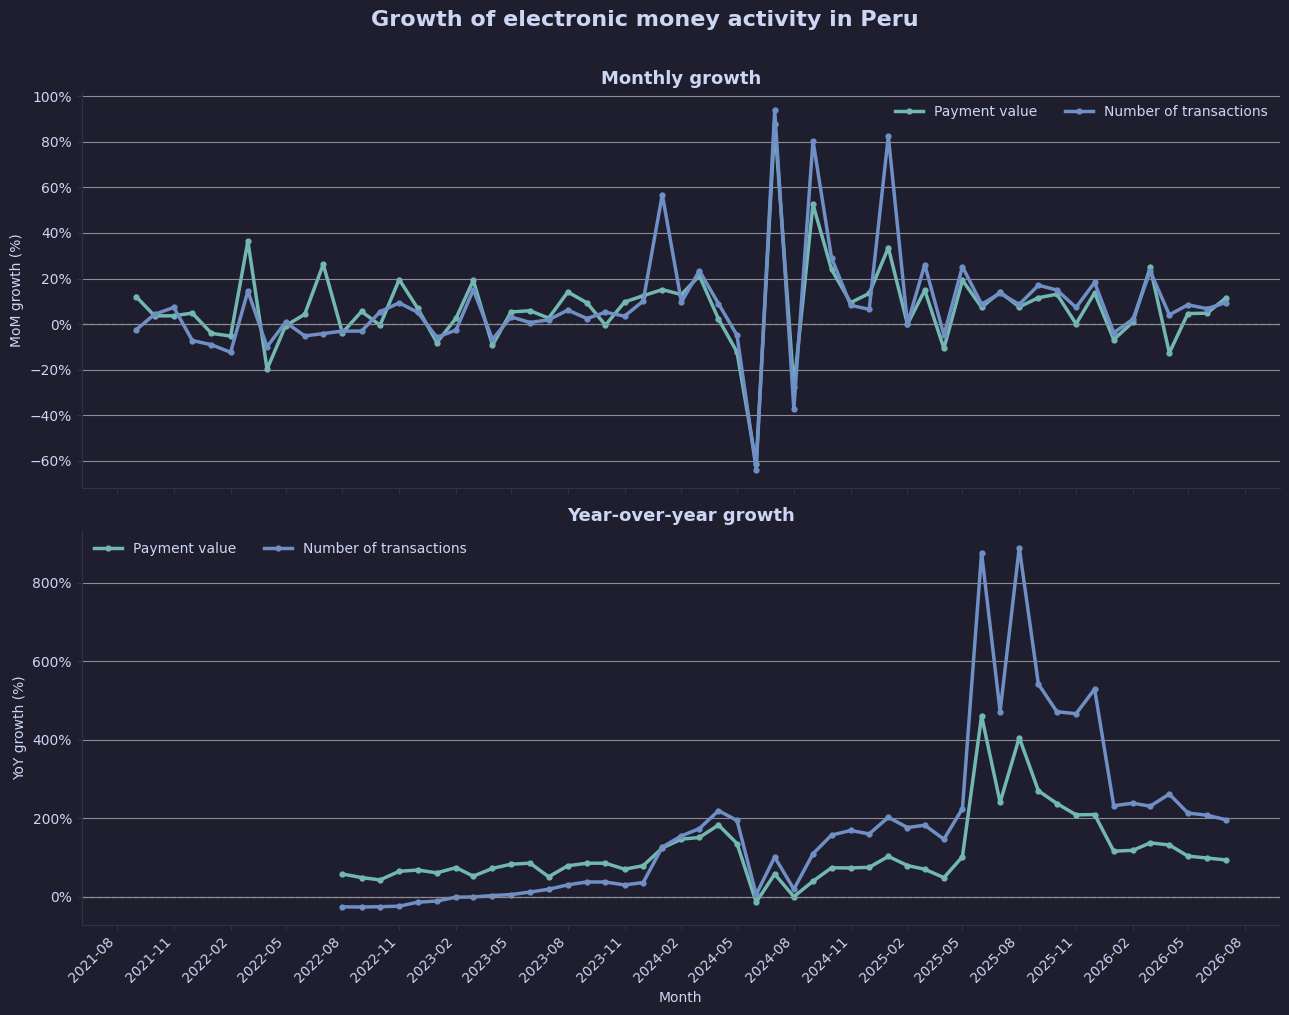

In [28]:
electronic_data = electronic_data.sort_values("period").copy()

# Monthly growth
electronic_data["var_mto_m"] = electronic_data["mto_dinero_electronico"].pct_change()

electronic_data["var_ntrx_m"] = electronic_data["ntrx_dinero_electronico"].pct_change()

# Year-over-year growth
electronic_data["var_mto_yoy"] = electronic_data["mto_dinero_electronico"].pct_change(
    12
)

electronic_data["var_ntrx_yoy"] = electronic_data["ntrx_dinero_electronico"].pct_change(
    12
)

# Pastel corporate colors
value_color = "#72B7B2"
transactions_color = "#6F8FC5"

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 10),
    sharex=True,
)

# ---------------------------------------------------------------
# Monthly growth
# ---------------------------------------------------------------

axes[0].plot(
    electronic_data["period"],
    electronic_data["var_mto_m"],
    color=value_color,
    linewidth=2.5,
    marker="o",
    markersize=3.5,
    label="Payment value",
)

axes[0].plot(
    electronic_data["period"],
    electronic_data["var_ntrx_m"],
    color=transactions_color,
    linewidth=2.5,
    marker="o",
    markersize=3.5,
    label="Number of transactions",
)

axes[0].axhline(
    0,
    color="#8C8C8C",
    linewidth=1,
    linestyle="--",
    alpha=0.7,
)

axes[0].set_title(
    "Monthly growth",
    fontsize=13,
    fontweight="bold",
)

axes[0].set_ylabel("MoM growth (%)")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].legend(frameon=False, ncol=2)

# ---------------------------------------------------------------
# Year-over-year growth
# ---------------------------------------------------------------

axes[1].plot(
    electronic_data["period"],
    electronic_data["var_mto_yoy"],
    color=value_color,
    linewidth=2.5,
    marker="o",
    markersize=3.5,
    label="Payment value",
)

axes[1].plot(
    electronic_data["period"],
    electronic_data["var_ntrx_yoy"],
    color=transactions_color,
    linewidth=2.5,
    marker="o",
    markersize=3.5,
    label="Number of transactions",
)

axes[1].axhline(
    0,
    color="#8C8C8C",
    linewidth=1,
    linestyle="--",
    alpha=0.7,
)

axes[1].set_title(
    "Year-over-year growth",
    fontsize=13,
    fontweight="bold",
)

axes[1].set_ylabel("YoY growth (%)")
axes[1].set_xlabel("Month")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].legend(frameon=False, ncol=2)

# ---------------------------------------------------------------
# General formatting
# ---------------------------------------------------------------

for ax in axes:
    ax.grid(
        axis="y",
        color="#D9D9D9",
        linewidth=0.8,
        alpha=0.6,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.setp(
    axes[1].get_xticklabels(),
    rotation=45,
    ha="right",
)

fig.suptitle(
    "Growth of electronic money activity in Peru",
    fontsize=16,
    fontweight="bold",
    y=1.01,
)

plt.tight_layout()
plt.show()